In [1]:
from pathlib import Path

import numpy as np
import pandas as pd


for candidate in (
    Path.cwd(),
    *Path.cwd().parents,
):
    if (
        candidate
        / "pyproject.toml"
    ).is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not locate the repository root."
    )


RUNS_ROOT = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
)

EVALUATION_NAME = (
    "irregular_object_eval"
)


SELECTED_FILENAMES = [
    (
        "400-1293-17-c11k1r5_pd_"
        "sp1_2_fl0_1_right.tif"
    ),
    (
        "400-1293-17-c11k1r5_pd_"
        "sp1_2_fl0_1_left.tif"
    ),
    (
        "400-1293-w14_c05k1r6_sp0_2_"
        "flow0_1_top_right.tif"
    ),
    (
        "400-1093-w11-c1p1-befo3-"
        "10sp-15flow_right.tif"
    ),
    "400-1605-W7_map_00021_4.tif",
]


NOISE_LEVELS = {
    1: {
        "gaussian_sigma": 0.05,
        "snp_amount": 0.05,
    },
    2: {
        "gaussian_sigma": 0.10,
        "snp_amount": 0.10,
    },
    3: {
        "gaussian_sigma": 0.20,
        "snp_amount": 0.20,
    },
    4: {
        "gaussian_sigma": 0.30,
        "snp_amount": 0.30,
    },
}


NOISE_LABELS = {
    "gaussian": "Gaussian",
    "snp": "Salt and pepper",
    "both": "Combined",
}

In [2]:
clean_metrics_path = (
    RUNS_ROOT
    / "batch1_seed_0_optimized_test_no_smoothing"
    / "eval"
    / EVALUATION_NAME
    / "object_metrics_per_image_threshold.csv"
)


if not clean_metrics_path.is_file():
    raise FileNotFoundError(
        f"Missing clean metrics:\n"
        f"{clean_metrics_path}"
    )


clean_all_images_df = pd.read_csv(
    clean_metrics_path
)


clean_all_images_df["filename"] = (
    clean_all_images_df["filename"]
    .astype(str)
    .map(
        lambda value:
        Path(value).name
    )
)


clean_object_metrics_df = (
    clean_all_images_df.loc[
        clean_all_images_df[
            "filename"
        ].isin(
            SELECTED_FILENAMES
        )
    ]
    .copy()
)


if len(clean_object_metrics_df) != 50:
    raise RuntimeError(
        "Expected 5 clean images x 10 "
        "thresholds = 50 rows; found "
        f"{len(clean_object_metrics_df)}."
    )


if (
    clean_object_metrics_df[
        "filename"
    ].nunique()
    != 5
):
    raise RuntimeError(
        "The clean baseline does not contain "
        "all five selected images."
    )


clean_object_metrics_df[
    "condition"
] = "clean"

clean_object_metrics_df[
    "noise_type"
] = "clean"

clean_object_metrics_df[
    "noise_label"
] = "Clean"

clean_object_metrics_df[
    "stage"
] = 0

clean_object_metrics_df[
    "gaussian_sigma"
] = 0.0

clean_object_metrics_df[
    "snp_amount"
] = 0.0


print(
    "Clean rows:",
    len(clean_object_metrics_df),
)

print(
    "Clean images:",
    clean_object_metrics_df[
        "filename"
    ].nunique(),
)

print(
    "Clean thresholds:",
    clean_object_metrics_df[
        "threshold"
    ].nunique(),
)

Clean rows: 50
Clean images: 5
Clean thresholds: 10


In [3]:
noisy_tables = []
load_checks = []


for stage in range(1, 5):
    for noise_type in (
        "gaussian",
        "snp",
        "both",
    ):
        run_name = (
            f"batch1_seed_0_noise_"
            f"stage_{stage}_{noise_type}"
        )

        metrics_path = (
            RUNS_ROOT
            / run_name
            / "eval"
            / EVALUATION_NAME
            / (
                "object_metrics_per_"
                "image_threshold.csv"
            )
        )

        if not metrics_path.is_file():
            raise FileNotFoundError(
                f"Missing evaluation table:\n"
                f"{metrics_path}"
            )

        table = pd.read_csv(
            metrics_path
        )

        table["filename"] = (
            table["filename"]
            .astype(str)
            .map(
                lambda value:
                Path(value).name
            )
        )

        image_count = table[
            "filename"
        ].nunique()

        threshold_count = table[
            "threshold"
        ].nunique()

        matching_metrics = sorted(
            table[
                "matching_metric"
            ]
            .dropna()
            .unique()
            .tolist()
        )

        status = "PASS"

        if (
            len(table) != 50
            or image_count != 5
            or threshold_count != 10
            or matching_metrics
            != ["cldice"]
        ):
            status = "INVALID"

        load_checks.append(
            {
                "stage": stage,
                "noise_type": noise_type,
                "rows": len(table),
                "images": image_count,
                "thresholds": (
                    threshold_count
                ),
                "matching_metrics": (
                    ", ".join(
                        matching_metrics
                    )
                ),
                "status": status,
            }
        )

        table["condition"] = (
            f"stage_{stage}_{noise_type}"
        )

        table["noise_type"] = (
            noise_type
        )

        table["noise_label"] = (
            NOISE_LABELS[
                noise_type
            ]
        )

        table["stage"] = stage

        table["gaussian_sigma"] = (
            NOISE_LEVELS[stage][
                "gaussian_sigma"
            ]
            if noise_type
            in {
                "gaussian",
                "both",
            }
            else 0.0
        )

        table["snp_amount"] = (
            NOISE_LEVELS[stage][
                "snp_amount"
            ]
            if noise_type
            in {
                "snp",
                "both",
            }
            else 0.0
        )

        table["run_name"] = run_name
        table["metrics_path"] = str(
            metrics_path
        )

        noisy_tables.append(
            table
        )


noise_load_checks_df = pd.DataFrame(
    load_checks
)


display(
    noise_load_checks_df
)


if not noise_load_checks_df[
    "status"
].eq("PASS").all():
    raise RuntimeError(
        "At least one noisy evaluation table "
        "failed validation."
    )


noisy_object_metrics_df = pd.concat(
    noisy_tables,
    ignore_index=True,
)


print(
    "Total noisy rows:",
    len(noisy_object_metrics_df),
)

print(
    "Noisy conditions:",
    noisy_object_metrics_df[
        "condition"
    ].nunique(),
)

,stage,noise_type,rows,images,thresholds,matching_metrics,status
0,1,gaussian,50,5,10,cldice,PASS
1,1,snp,50,5,10,cldice,PASS
2,1,both,50,5,10,cldice,PASS
3,2,gaussian,50,5,10,cldice,PASS
4,2,snp,50,5,10,cldice,PASS
5,2,both,50,5,10,cldice,PASS
6,3,gaussian,50,5,10,cldice,PASS
7,3,snp,50,5,10,cldice,PASS
8,3,both,50,5,10,cldice,PASS
9,4,gaussian,50,5,10,cldice,PASS


Total noisy rows: 600
Noisy conditions: 12


In [4]:
all_object_metrics_df = pd.concat(
    [
        clean_object_metrics_df,
        noisy_object_metrics_df,
    ],
    ignore_index=True,
)


print(
    "Total rows including clean baseline:",
    len(all_object_metrics_df),
)

print(
    "Images:",
    all_object_metrics_df[
        "filename"
    ].nunique(),
)

print(
    "Conditions:",
    all_object_metrics_df[
        "condition"
    ].nunique(),
)


condition_counts_df = (
    all_object_metrics_df
    .groupby(
        [
            "condition",
            "noise_label",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        rows=(
            "f1_score",
            "size",
        ),
        images=(
            "filename",
            "nunique",
        ),
        thresholds=(
            "threshold",
            "nunique",
        ),
        mean_predictions=(
            "num_pred_objects",
            "mean",
        ),
    )
    .sort_values(
        [
            "stage",
            "noise_label",
        ]
    )
)


display(
    condition_counts_df
)

Total rows including clean baseline: 650
Images: 5
Conditions: 13


,condition,noise_label,stage,rows,images,thresholds,mean_predictions
0,clean,Clean,0,50,5,10,67.0
1,stage_1_both,Combined,1,50,5,10,71.4
2,stage_1_gaussian,Gaussian,1,50,5,10,67.0
3,stage_1_snp,Salt and pepper,1,50,5,10,68.8
4,stage_2_both,Combined,2,50,5,10,68.2
5,stage_2_gaussian,Gaussian,2,50,5,10,63.0
6,stage_2_snp,Salt and pepper,2,50,5,10,73.4
7,stage_3_both,Combined,3,50,5,10,11.4
8,stage_3_gaussian,Gaussian,3,50,5,10,56.6
9,stage_3_snp,Salt and pepper,3,50,5,10,57.2


# first comparison table

This summarizes F1 in two ways:

at the paper’s fixed clDice threshold of 0.5;
averaged across all ten clDice thresholds.

In [5]:
threshold_f1_summary_df = (
    all_object_metrics_df
    .groupby(
        [
            "condition",
            "noise_label",
            "noise_type",
            "stage",
            "gaussian_sigma",
            "snp_amount",
            "threshold",
        ],
        as_index=False,
    )
    .agg(
        mean_f1=(
            "f1_score",
            "mean",
        ),
        std_f1=(
            "f1_score",
            "std",
        ),
        minimum_f1=(
            "f1_score",
            "min",
        ),
        maximum_f1=(
            "f1_score",
            "max",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
)


expected_condition_count = 13
expected_threshold_count = 10
expected_rows = (
    expected_condition_count
    * expected_threshold_count
)


if (
    threshold_f1_summary_df[
        "condition"
    ].nunique()
    != expected_condition_count
):
    raise RuntimeError(
        "Expected 13 conditions: one clean "
        "condition and 12 noisy conditions."
    )


if (
    threshold_f1_summary_df[
        "threshold"
    ].nunique()
    != expected_threshold_count
):
    raise RuntimeError(
        "Expected exactly 10 clDice thresholds."
    )


if len(
    threshold_f1_summary_df
) != expected_rows:
    raise RuntimeError(
        f"Expected {expected_rows} summarized "
        "rows; found "
        f"{len(threshold_f1_summary_df)}."
    )


if not threshold_f1_summary_df[
    "image_count"
].eq(5).all():
    raise RuntimeError(
        "Each condition and threshold must "
        "contain exactly five image-level "
        "F1 scores."
    )


threshold_f1_summary_df = (
    threshold_f1_summary_df
    .sort_values(
        [
            "stage",
            "noise_type",
            "threshold",
        ]
    )
    .reset_index(drop=True)
)


print(
    "Conditions:",
    threshold_f1_summary_df[
        "condition"
    ].nunique(),
)

print(
    "Thresholds:",
    threshold_f1_summary_df[
        "threshold"
    ].nunique(),
)

print(
    "Summary rows:",
    len(
        threshold_f1_summary_df
    ),
)


display(
    threshold_f1_summary_df
)

Conditions: 13
Thresholds: 10
Summary rows: 130


,condition,noise_label,noise_type,stage,gaussian_sigma,snp_amount,threshold,mean_f1,std_f1,minimum_f1,maximum_f1,image_count
0,clean,Clean,clean,0,0.0,0.0,0.1,0.871702,0.036838,0.805970,0.890909,5
1,clean,Clean,clean,0,0.0,0.0,0.2,0.870569,0.036455,0.805970,0.890909,5
2,clean,Clean,clean,0,0.0,0.0,0.3,0.859415,0.040633,0.791045,0.888889,5
3,clean,Clean,clean,0,0.0,0.0,0.4,0.853749,0.043205,0.791045,0.888889,5
4,clean,Clean,clean,0,0.0,0.0,0.5,0.840743,0.054972,0.761194,0.888889,5
...,...,...,...,...,...,...,...,...,...,...,...,...
125,stage_4_snp,Salt and pepper,snp,4,0.0,0.3,0.6,0.121606,0.135192,0.029851,0.333333,5
126,stage_4_snp,Salt and pepper,snp,4,0.0,0.3,0.7,0.109482,0.146012,0.000000,0.333333,5
127,stage_4_snp,Salt and pepper,snp,4,0.0,0.3,0.8,0.051515,0.075454,0.000000,0.166667,5
128,stage_4_snp,Salt and pepper,snp,4,0.0,0.3,0.9,0.018182,0.040656,0.000000,0.090909,5


C:\Users\abd93000\AppData\Local\Temp\ipykernel_22408\4289763310.py:184: UserWarning: Glyph 8212 (\N{EM DASH}) missing from font(s) cmr10.
  figure.tight_layout()


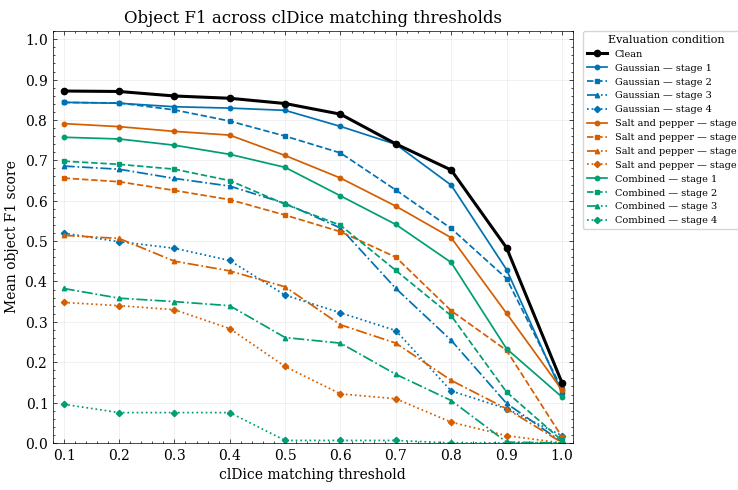

In [6]:
import matplotlib.pyplot as plt
import scienceplots

CONDITION_COLORS = {
    "gaussian": "#0072B2",
    "snp": "#D55E00",
    "both": "#009E73",
}

STAGE_LINESTYLES = {
    1: "-",
    2: "--",
    3: "-.",
    4: ":",
}

STAGE_MARKERS = {
    1: "o",
    2: "s",
    3: "^",
    4: "D",
}


with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    figure, axis = plt.subplots(
        figsize=(
            7.5,
            5.0,
        )
    )

    clean_table = (
        threshold_f1_summary_df.loc[
            threshold_f1_summary_df[
                "condition"
            ].eq("clean")
        ]
        .sort_values("threshold")
    )

    axis.plot(
        clean_table["threshold"],
        clean_table["mean_f1"],
        color="black",
        linestyle="-",
        marker="o",
        markersize=4.5,
        linewidth=2.2,
        label="Clean",
        zorder=10,
    )


    for noise_type in (
        "gaussian",
        "snp",
        "both",
    ):
        for stage in (
            1,
            2,
            3,
            4,
        ):
            condition = (
                f"stage_{stage}_"
                f"{noise_type}"
            )

            condition_table = (
                threshold_f1_summary_df.loc[
                    threshold_f1_summary_df[
                        "condition"
                    ].eq(condition)
                ]
                .sort_values(
                    "threshold"
                )
            )

            if len(condition_table) != 10:
                raise RuntimeError(
                    f"{condition} does not "
                    "contain 10 thresholds."
                )

            axis.plot(
                condition_table[
                    "threshold"
                ],
                condition_table[
                    "mean_f1"
                ],
                color=(
                    CONDITION_COLORS[
                        noise_type
                    ]
                ),
                linestyle=(
                    STAGE_LINESTYLES[
                        stage
                    ]
                ),
                marker=(
                    STAGE_MARKERS[
                        stage
                    ]
                ),
                markersize=3.2,
                linewidth=1.25,
                label=(
                    f"{NOISE_LABELS[noise_type]} "
                    f"— stage {stage}"
                ),
            )


    axis.set_title(
        (
            "Object F1 across clDice "
            "matching thresholds"
        )
    )

    axis.set_xlabel(
        "clDice matching threshold"
    )

    axis.set_ylabel(
        "Mean object F1 score"
    )

    axis.set_xticks(
        np.arange(
            0.1,
            1.01,
            0.1,
        )
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.1,
        )
    )

    axis.set_xlim(
        0.08,
        1.02,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )

    axis.grid(
        alpha=0.25,
    )

    axis.legend(
        title=(
            "Evaluation condition"
        ),
        fontsize=7,
        title_fontsize=8,
        frameon=True,
        bbox_to_anchor=(
            1.02,
            1.0,
        ),
        loc="upper left",
        borderaxespad=0.0,
    )

    figure.tight_layout()


plt.show()

C:\Users\abd93000\AppData\Local\Temp\ipykernel_22408\1016111588.py:270: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  figure.tight_layout()


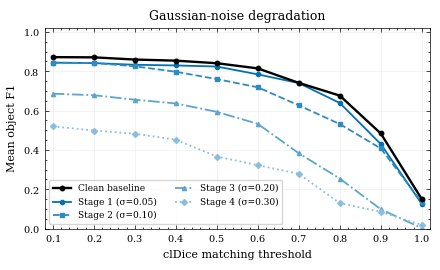

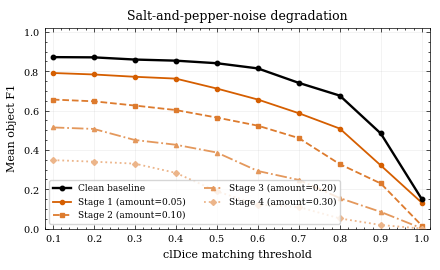

C:\Users\abd93000\AppData\Local\Temp\ipykernel_22408\1016111588.py:270: UserWarning: Glyph 963 (\N{GREEK SMALL LETTER SIGMA}) missing from font(s) cmr10.
  figure.tight_layout()


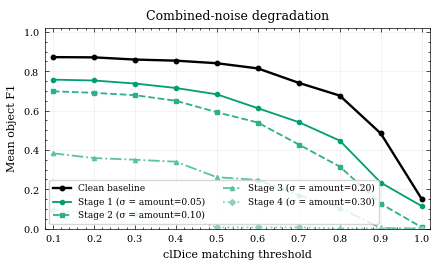

In [7]:
# %%
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


NOISE_PLOT_SETTINGS = {
    "gaussian": {
        "title": "Gaussian-noise degradation",
        "base_color": "#0072B2",
        "parameter_label": "σ",
    },
    "snp": {
        "title": (
            "Salt-and-pepper-noise degradation"
        ),
        "base_color": "#D55E00",
        "parameter_label": "amount",
    },
    "both": {
        "title": "Combined-noise degradation",
        "base_color": "#009E73",
        "parameter_label": "σ = amount",
    },
}


STAGE_LINESTYLES = {
    1: "-",
    2: "--",
    3: "-.",
    4: ":",
}


STAGE_MARKERS = {
    1: "o",
    2: "s",
    3: "^",
    4: "D",
}


STAGE_LIGHTENING = {
    1: 0.00,
    2: 0.18,
    3: 0.36,
    4: 0.54,
}


def lighten_color(
    color,
    amount,
):
    """
    Mix a color with white.

    amount=0 returns the original color;
    larger values return progressively
    lighter colors.
    """
    rgb = np.asarray(
        mcolors.to_rgb(
            color
        ),
        dtype=float,
    )

    white = np.ones(
        3,
        dtype=float,
    )

    lightened = (
        (1.0 - amount) * rgb
        + amount * white
    )

    return tuple(
        lightened
    )


clean_table = (
    threshold_f1_summary_df.loc[
        threshold_f1_summary_df[
            "condition"
        ].eq("clean")
    ]
    .sort_values("threshold")
)


noise_degradation_figures = {}


for noise_type in (
    "gaussian",
    "snp",
    "both",
):
    settings = (
        NOISE_PLOT_SETTINGS[
            noise_type
        ]
    )

    with plt.style.context(
        [
            "science",
            "no-latex",
        ]
    ):
        figure, axis = plt.subplots(
            figsize=(
                4.5,
                2.8,
            )
        )


        # Model performance on clean images.
        axis.plot(
            clean_table["threshold"],
            clean_table["mean_f1"],
            color="black",
            linestyle="-",
            marker="o",
            markersize=3.2,
            linewidth=1.7,
            label="Clean baseline",
            zorder=10,
        )


        for stage in (
            1,
            2,
            3,
            4,
        ):
            condition = (
                f"stage_{stage}_"
                f"{noise_type}"
            )

            condition_table = (
                threshold_f1_summary_df.loc[
                    threshold_f1_summary_df[
                        "condition"
                    ].eq(condition)
                ]
                .sort_values(
                    "threshold"
                )
            )

            if len(condition_table) != 10:
                raise RuntimeError(
                    f"{condition} does not "
                    "contain 10 thresholds."
                )

            noise_level = (
                NOISE_LEVELS[stage][
                    "gaussian_sigma"
                ]
                if noise_type
                == "gaussian"
                else
                NOISE_LEVELS[stage][
                    "snp_amount"
                ]
            )

            stage_color = lighten_color(
                settings["base_color"],
                STAGE_LIGHTENING[
                    stage
                ],
            )

            label = (
                f"Stage {stage} "
                f"({settings['parameter_label']}="
                f"{noise_level:.2f})"
            )

            axis.plot(
                condition_table[
                    "threshold"
                ],
                condition_table[
                    "mean_f1"
                ],
                color=stage_color,
                linestyle=(
                    STAGE_LINESTYLES[
                        stage
                    ]
                ),
                marker=(
                    STAGE_MARKERS[
                        stage
                    ]
                ),
                markersize=3.0,
                linewidth=1.3,
                label=label,
            )


        axis.set_title(
            settings["title"],
            fontsize=9,
        )

        axis.set_xlabel(
            "clDice matching threshold",
            fontsize=8,
        )

        axis.set_ylabel(
            "Mean object F1",
            fontsize=8,
        )

        axis.set_xticks(
            np.arange(
                0.1,
                1.01,
                0.1,
            )
        )

        axis.set_yticks(
            np.arange(
                0.0,
                1.01,
                0.2,
            )
        )

        axis.set_xlim(
            0.08,
            1.02,
        )

        axis.set_ylim(
            0.0,
            1.02,
        )

        axis.tick_params(
            axis="both",
            labelsize=7,
        )

        axis.grid(
            alpha=0.20,
        )

        axis.legend(
            fontsize=6.5,
            frameon=True,
            ncol=2,
            loc="lower left",
        )

        figure.tight_layout()


    noise_degradation_figures[
        noise_type
    ] = figure

    plt.show()

In [8]:
per_image_mean_f1_df = (
    all_object_metrics_df
    .groupby(
        [
            "condition",
            "noise_type",
            "noise_label",
            "stage",
            "filename",
        ],
        as_index=False,
    )
    .agg(
        mean_f1_across_thresholds=(
            "f1_score",
            "mean",
        ),
        threshold_count=(
            "threshold",
            "nunique",
        ),
    )
)


if not per_image_mean_f1_df[
    "threshold_count"
].eq(10).all():
    raise RuntimeError(
        "Every image-condition combination "
        "must contain exactly 10 thresholds."
    )


condition_image_counts = (
    per_image_mean_f1_df
    .groupby("condition")[
        "filename"
    ]
    .nunique()
)


if not condition_image_counts.eq(5).all():
    raise RuntimeError(
        "Every condition must contain exactly "
        "five images."
    )


display(
    per_image_mean_f1_df
)

,condition,noise_type,noise_label,stage,filename,mean_f1_across_thresholds,threshold_count
0,clean,clean,Clean,0,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,0.659490,10
1,clean,clean,Clean,0,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif,0.777778,10
2,clean,clean,Clean,0,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif,0.822222,10
3,clean,clean,Clean,0,400-1293-w14_c05k1r6_sp0_2_flow0_1_top_right.tif,0.707273,10
4,clean,clean,Clean,0,400-1605-W7_map_00021_4.tif,0.613433,10
...,...,...,...,...,...,...,...
60,stage_4_snp,snp,Salt and pepper,4,400-1093-w11-c1p1-befo3-10sp-15flow_right.tif,0.068657,10
61,stage_4_snp,snp,Salt and pepper,4,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_left.tif,0.327273,10
62,stage_4_snp,snp,Salt and pepper,4,400-1293-17-c11k1r5_pd_sp1_2_fl0_1_right.tif,0.400000,10
63,stage_4_snp,snp,Salt and pepper,4,400-1293-w14_c05k1r6_sp0_2_flow0_1_top_right.tif,0.067692,10


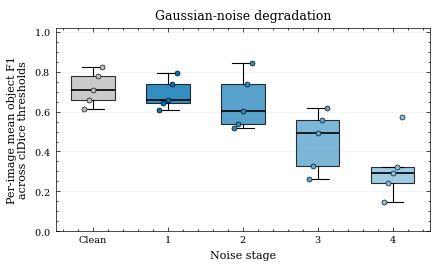

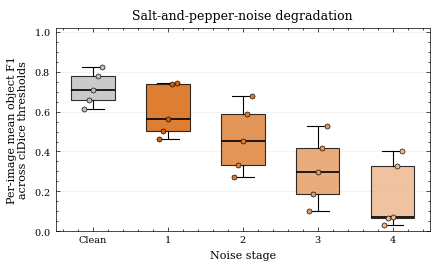

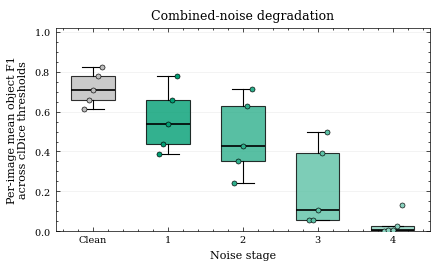

In [9]:
BOXPLOT_SETTINGS = {
    "gaussian": {
        "title": "Gaussian-noise degradation",
        "base_color": "#0072B2",
    },
    "snp": {
        "title": (
            "Salt-and-pepper-noise degradation"
        ),
        "base_color": "#D55E00",
    },
    "both": {
        "title": "Combined-noise degradation",
        "base_color": "#009E73",
    },
}


noise_boxplot_figures = {}


for noise_type in (
    "gaussian",
    "snp",
    "both",
):
    plotting_groups = []

    clean_values = (
        per_image_mean_f1_df.loc[
            per_image_mean_f1_df[
                "condition"
            ].eq("clean"),
            "mean_f1_across_thresholds",
        ]
        .to_numpy(dtype=float)
    )

    plotting_groups.append(
        clean_values
    )


    for stage in (
        1,
        2,
        3,
        4,
    ):
        condition = (
            f"stage_{stage}_"
            f"{noise_type}"
        )

        stage_values = (
            per_image_mean_f1_df.loc[
                per_image_mean_f1_df[
                    "condition"
                ].eq(condition),
                "mean_f1_across_thresholds",
            ]
            .to_numpy(dtype=float)
        )

        if len(stage_values) != 5:
            raise RuntimeError(
                f"{condition} does not contain "
                "exactly five image-level values."
            )

        plotting_groups.append(
            stage_values
        )


    box_colors = [
        "#BDBDBD",
        *[
            lighten_color(
                BOXPLOT_SETTINGS[
                    noise_type
                ]["base_color"],
                STAGE_LIGHTENING[
                    stage
                ],
            )
            for stage in (
                1,
                2,
                3,
                4,
            )
        ],
    ]


    with plt.style.context(
        [
            "science",
            "no-latex",
        ]
    ):
        figure, axis = plt.subplots(
            figsize=(
                4.5,
                2.8,
            )
        )


        boxplot = axis.boxplot(
            plotting_groups,
            positions=[
                0,
                1,
                2,
                3,
                4,
            ],
            widths=0.58,
            patch_artist=True,
            showfliers=False,
            medianprops={
                "color": "black",
                "linewidth": 1.2,
            },
            whiskerprops={
                "color": "black",
                "linewidth": 0.8,
            },
            capprops={
                "color": "black",
                "linewidth": 0.8,
            },
            boxprops={
                "color": "black",
                "linewidth": 0.8,
            },
        )


        for box, color in zip(
            boxplot["boxes"],
            box_colors,
        ):
            box.set_facecolor(
                color
            )

            box.set_alpha(
                0.80
            )


        # Show all five image-level observations.
        point_offsets = np.linspace(
            -0.12,
            0.12,
            5,
        )

        for position, (
            values,
            color,
        ) in enumerate(
            zip(
                plotting_groups,
                box_colors,
            )
        ):
            sorted_values = np.sort(
                values
            )

            axis.scatter(
                position
                + point_offsets,
                sorted_values,
                s=13,
                facecolor=color,
                edgecolor="black",
                linewidth=0.45,
                zorder=4,
            )


        axis.set_title(
            BOXPLOT_SETTINGS[
                noise_type
            ]["title"],
            fontsize=9,
        )

        axis.set_xlabel(
            "Noise stage",
            fontsize=8,
        )

        axis.set_ylabel(
            (
                "Per-image mean object F1\n"
                "across clDice thresholds"
            ),
            fontsize=8,
        )

        axis.set_xticks(
            [
                0,
                1,
                2,
                3,
                4,
            ]
        )

        axis.set_xticklabels(
            [
                "Clean",
                "1",
                "2",
                "3",
                "4",
            ]
        )

        axis.set_ylim(
            0.0,
            1.02,
        )

        axis.set_yticks(
            np.arange(
                0.0,
                1.01,
                0.2,
            )
        )

        axis.tick_params(
            axis="both",
            labelsize=7,
        )

        axis.grid(
            axis="y",
            alpha=0.20,
        )

        figure.tight_layout()


    noise_boxplot_figures[
        noise_type
    ] = figure

    plt.show()

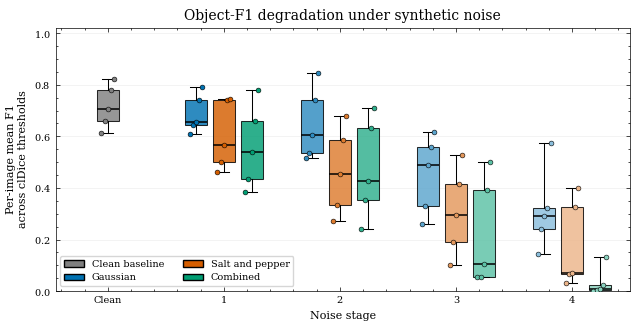

In [10]:
# %%
from matplotlib.patches import Patch


NOISE_COLORS = {
    "gaussian": "#0072B2",
    "snp": "#D55E00",
    "both": "#009E73",
}


NOISE_OFFSETS = {
    "gaussian": -0.24,
    "snp": 0.00,
    "both": 0.24,
}


NOISE_NAMES = {
    "gaussian": "Gaussian",
    "snp": "Salt and pepper",
    "both": "Combined",
}


def draw_f1_box(
    axis,
    *,
    values,
    position,
    color,
):
    result = axis.boxplot(
        [
            values,
        ],
        positions=[
            position,
        ],
        widths=0.19,
        patch_artist=True,
        showfliers=False,
        whis=(
            0,
            100,
        ),
        medianprops={
            "color": "black",
            "linewidth": 1.1,
        },
        whiskerprops={
            "color": "black",
            "linewidth": 0.75,
        },
        capprops={
            "color": "black",
            "linewidth": 0.75,
        },
        boxprops={
            "color": "black",
            "linewidth": 0.75,
        },
    )

    result["boxes"][0].set_facecolor(
        color
    )

    result["boxes"][0].set_alpha(
        0.82
    )

    # Display all five image-level values.
    point_offsets = np.linspace(
        -0.055,
        0.055,
        len(values),
    )

    axis.scatter(
        position + point_offsets,
        np.sort(values),
        s=12,
        facecolor=color,
        edgecolor="black",
        linewidth=0.4,
        zorder=4,
    )


with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    grouped_boxplot_figure, axis = (
        plt.subplots(
            figsize=(
                6.5,
                3.4,
            )
        )
    )


    # Clean baseline at stage zero.
    clean_values = (
        per_image_mean_f1_df.loc[
            per_image_mean_f1_df[
                "condition"
            ].eq("clean"),
            "mean_f1_across_thresholds",
        ]
        .to_numpy(dtype=float)
    )

    if len(clean_values) != 5:
        raise RuntimeError(
            "The clean baseline does not "
            "contain five image-level values."
        )

    draw_f1_box(
        axis,
        values=clean_values,
        position=0.0,
        color="#808080",
    )


    # Three noise conditions at stages 1–4.
    for stage in (
        1,
        2,
        3,
        4,
    ):
        for noise_type in (
            "gaussian",
            "snp",
            "both",
        ):
            condition = (
                f"stage_{stage}_"
                f"{noise_type}"
            )

            values = (
                per_image_mean_f1_df.loc[
                    per_image_mean_f1_df[
                        "condition"
                    ].eq(condition),
                    (
                        "mean_f1_"
                        "across_thresholds"
                    ),
                ]
                .to_numpy(dtype=float)
            )

            if len(values) != 5:
                raise RuntimeError(
                    f"{condition} does not "
                    "contain five values."
                )

            stage_color = lighten_color(
                NOISE_COLORS[
                    noise_type
                ],
                STAGE_LIGHTENING[
                    stage
                ],
            )

            position = (
                stage
                + NOISE_OFFSETS[
                    noise_type
                ]
            )

            draw_f1_box(
                axis,
                values=values,
                position=position,
                color=stage_color,
            )


    axis.set_title(
        (
            "Object-F1 degradation under "
            "synthetic noise"
        ),
        fontsize=10,
    )

    axis.set_xlabel(
        "Noise stage",
        fontsize=8,
    )

    axis.set_ylabel(
        (
            "Per-image mean F1\n"
            "across clDice thresholds"
        ),
        fontsize=8,
    )

    axis.set_xticks(
        [
            0,
            1,
            2,
            3,
            4,
        ]
    )

    axis.set_xticklabels(
        [
            "Clean",
            "1",
            "2",
            "3",
            "4",
        ]
    )

    axis.set_xlim(
        -0.45,
        4.5,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    axis.tick_params(
        axis="both",
        labelsize=7,
    )

    axis.grid(
        axis="y",
        alpha=0.20,
    )


    legend_handles = [
        Patch(
            facecolor="#808080",
            edgecolor="black",
            label="Clean baseline",
        ),
        *[
            Patch(
                facecolor=(
                    NOISE_COLORS[
                        noise_type
                    ]
                ),
                edgecolor="black",
                label=(
                    NOISE_NAMES[
                        noise_type
                    ]
                ),
            )
            for noise_type in (
                "gaussian",
                "snp",
                "both",
            )
        ],
    ]


    axis.legend(
        handles=legend_handles,
        fontsize=7,
        frameon=True,
        ncol=2,
        loc="lower left",
    )

    grouped_boxplot_figure.tight_layout()


plt.show()

In [11]:
NOISE_COLORS = {
    "gaussian": "#0072B2",
    "snp": "#D55E00",
    "both": "#009E73",
}


NOISE_NAMES = {
    "gaussian": "Gaussian",
    "snp": "Salt and pepper",
    "both": "Combined",
}


NOISE_MARKERS = {
    "gaussian": "o",
    "snp": "s",
    "both": "D",
}


# Mean across the five image-level values.
condition_mean_f1_df = (
    per_image_mean_f1_df
    .groupby(
        [
            "condition",
            "noise_type",
            "stage",
        ],
        as_index=False,
    )
    .agg(
        mean_f1=(
            "mean_f1_across_thresholds",
            "mean",
        ),
        std_f1_across_images=(
            "mean_f1_across_thresholds",
            "std",
        ),
        image_count=(
            "filename",
            "nunique",
        ),
    )
)


if not condition_mean_f1_df[
    "image_count"
].eq(5).all():
    raise RuntimeError(
        "Every condition must contain "
        "exactly five images."
    )


clean_rows = (
    condition_mean_f1_df.loc[
        condition_mean_f1_df[
            "condition"
        ].eq("clean")
    ]
)


if len(clean_rows) != 1:
    raise RuntimeError(
        "Expected exactly one clean-baseline "
        "summary row."
    )


clean_mean_f1 = float(
    clean_rows.iloc[0][
        "mean_f1"
    ]
)

clean_std_f1 = float(
    clean_rows.iloc[0][
        "std_f1_across_images"
    ]
)


degradation_curve_rows = []


for noise_type in (
    "gaussian",
    "snp",
    "both",
):
    # All curves share the same clean baseline.
    degradation_curve_rows.append(
        {
            "noise_type": noise_type,
            "stage": 0,
            "mean_f1": clean_mean_f1,
            "std_f1": clean_std_f1,
            "image_count": 5,
        }
    )

    for stage in (
        1,
        2,
        3,
        4,
    ):
        condition = (
            f"stage_{stage}_"
            f"{noise_type}"
        )

        matching_rows = (
            condition_mean_f1_df.loc[
                condition_mean_f1_df[
                    "condition"
                ].eq(condition)
            ]
        )

        if len(matching_rows) != 1:
            raise RuntimeError(
                f"Expected one summary row "
                f"for {condition}; found "
                f"{len(matching_rows)}."
            )

        summary_row = (
            matching_rows.iloc[0]
        )

        degradation_curve_rows.append(
            {
                "noise_type": noise_type,
                "stage": stage,
                "mean_f1": float(
                    summary_row[
                        "mean_f1"
                    ]
                ),
                "std_f1": float(
                    summary_row[
                        "std_f1_across_images"
                    ]
                ),
                "image_count": int(
                    summary_row[
                        "image_count"
                    ]
                ),
            }
        )


degradation_curve_df = pd.DataFrame(
    degradation_curve_rows
)


display(
    degradation_curve_df
)

,noise_type,stage,mean_f1,std_f1,image_count
0,gaussian,0,0.716039,0.084984,5
1,gaussian,1,0.688783,0.075331,5
2,gaussian,2,0.648512,0.140553,5
3,gaussian,3,0.451847,0.151084,5
4,gaussian,4,0.315150,0.159771,5
5,snp,0,0.716039,0.084984,5
6,snp,1,0.602435,0.132117,5
7,snp,2,0.465122,0.169998,5
8,snp,3,0.306507,0.170538,5
9,snp,4,0.179176,0.170971,5


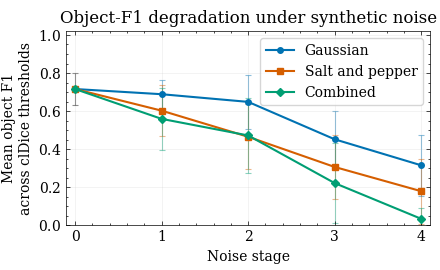

In [14]:
# %%
with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    degradation_figure, axis = (
        plt.subplots(
            figsize=(
                4.5,
                2.8,
            )
        )
    )


    for noise_type in (
        "gaussian",
        "snp",
        "both",
    ):
        curve = (
            degradation_curve_df.loc[
                degradation_curve_df[
                    "noise_type"
                ].eq(noise_type)
            ]
            .sort_values("stage")
        )

        color = (
            NOISE_COLORS[
                noise_type
            ]
        )


        # Fully opaque mean-degradation curve.
        axis.plot(
            curve["stage"],
            curve["mean_f1"],
            color=color,
            marker=(
                NOISE_MARKERS[
                    noise_type
                ]
            ),
            markersize=4,
            linewidth=1.5,
            label=(
                NOISE_NAMES[
                    noise_type
                ]
            ),
        )


        # Transparent uncertainty intervals.
        # Stage zero is excluded here because
        # all three curves use the same clean SD.
        noisy_curve = (
            curve.loc[
                curve["stage"].gt(0)
            ]
        )

        axis.errorbar(
            noisy_curve["stage"],
            noisy_curve["mean_f1"],
            yerr=noisy_curve["std_f1"],
            fmt="none",
            ecolor=mcolors.to_rgba(
                color,
                alpha=0.45,
            ),
            elinewidth=0.8,
            capsize=2.5,
            capthick=0.8,
            zorder=1,
        )


    # Draw the shared clean-image uncertainty
    # only once to avoid three overlapping bars.
    clean_curve_row = (
        degradation_curve_df.loc[
            degradation_curve_df[
                "stage"
            ].eq(0)
        ]
        .iloc[0]
    )

    axis.errorbar(
        [
            0,
        ],
        [
            clean_curve_row[
                "mean_f1"
            ],
        ],
        yerr=[
            clean_curve_row[
                "std_f1"
            ],
        ],
        fmt="none",
        ecolor=mcolors.to_rgba(
            "black",
            alpha=0.45,
        ),
        elinewidth=0.8,
        capsize=2.5,
        capthick=0.8,
        zorder=1,
    )


    axis.set_title(
        (
            "Object-F1 degradation under "
            "synthetic noise"
        )
    )

    axis.set_xlabel(
        "Noise stage"
    )

    axis.set_ylabel(
        (
            "Mean object F1\n"
            "across clDice thresholds"
        )
    )

    axis.set_xticks(
        [
            0,
            1,
            2,
            3,
            4,
        ]
    )

    axis.set_xticklabels(
        [
            "0",
            "1",
            "2",
            "3",
            "4",
        ]
    )

    axis.set_xlim(
        -0.10,
        4.10,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    axis.grid(
        alpha=0.20,
    )

    axis.legend(
        frameon=True,
        loc="best",
    )

    degradation_figure.tight_layout()


plt.show()

Saved PNG: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\R4.4_gradual_noise\object_f1_gradual_noise.png
Saved SVG: c:\Users\abd93000\PycharmProjects\cnt_project_v2\notebooks\review\R4.4_gradual_noise\object_f1_gradual_noise.svg
Figure size: [4.5 2.8]


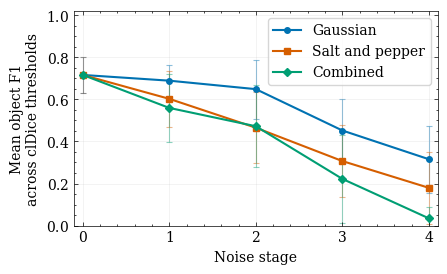

In [12]:
# %%
from pathlib import Path


FIGURE_SIZE = (
    4.5,
    2.8,
)

FIGURE_DPI = 600

OUTPUT_DIRECTORY = (
    PROJECT_ROOT
    / "notebooks"
    / "review"
    / "R4.4_gradual_noise"
)

OUTPUT_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

PNG_OUTPUT_PATH = (
    OUTPUT_DIRECTORY
    / "object_f1_gradual_noise.png"
)

SVG_OUTPUT_PATH = (
    OUTPUT_DIRECTORY
    / "object_f1_gradual_noise.svg"
)


with plt.style.context(
    [
        "science",
        "no-latex",
    ]
):
    degradation_figure, axis = (
        plt.subplots(
            figsize=FIGURE_SIZE,
        )
    )


    for noise_type in (
        "gaussian",
        "snp",
        "both",
    ):
        curve = (
            degradation_curve_df.loc[
                degradation_curve_df[
                    "noise_type"
                ].eq(noise_type)
            ]
            .sort_values("stage")
        )

        color = (
            NOISE_COLORS[
                noise_type
            ]
        )


        # Fully opaque mean-degradation curve.
        axis.plot(
            curve["stage"],
            curve["mean_f1"],
            color=color,
            marker=(
                NOISE_MARKERS[
                    noise_type
                ]
            ),
            markersize=4,
            linewidth=1.5,
            label=(
                NOISE_NAMES[
                    noise_type
                ]
            ),
        )


        # Transparent uncertainty intervals.
        # Stage zero is excluded here because
        # all three curves use the same clean SD.
        noisy_curve = (
            curve.loc[
                curve["stage"].gt(0)
            ]
        )

        axis.errorbar(
            noisy_curve["stage"],
            noisy_curve["mean_f1"],
            yerr=noisy_curve["std_f1"],
            fmt="none",
            ecolor=mcolors.to_rgba(
                color,
                alpha=0.45,
            ),
            elinewidth=0.8,
            capsize=2.5,
            capthick=0.8,
            zorder=1,
        )


    # Draw the shared clean-image uncertainty
    # only once to avoid three overlapping bars.
    clean_curve_row = (
        degradation_curve_df.loc[
            degradation_curve_df[
                "stage"
            ].eq(0)
        ]
        .iloc[0]
    )

    axis.errorbar(
        [
            0,
        ],
        [
            clean_curve_row[
                "mean_f1"
            ],
        ],
        yerr=[
            clean_curve_row[
                "std_f1"
            ],
        ],
        fmt="none",
        ecolor=mcolors.to_rgba(
            "black",
            alpha=0.45,
        ),
        elinewidth=0.8,
        capsize=2.5,
        capthick=0.8,
        zorder=1,
    )


    # axis.set_title(
    #     (
    #         "Object-F1 degradation under "
    #         "synthetic noise"
    #     )
    # )

    axis.set_xlabel(
        "Noise stage"
    )

    axis.set_ylabel(
        (
            "Mean object F1\n"
            "across clDice thresholds"
        )
    )

    axis.set_xticks(
        [
            0,
            1,
            2,
            3,
            4,
        ]
    )

    axis.set_xticklabels(
        [
            "0",
            "1",
            "2",
            "3",
            "4",
        ]
    )

    axis.set_xlim(
        -0.10,
        4.10,
    )

    axis.set_ylim(
        0.0,
        1.02,
    )

    axis.set_yticks(
        np.arange(
            0.0,
            1.01,
            0.2,
        )
    )

    axis.grid(
        alpha=0.20,
    )

    axis.legend(
        frameon=True,
        loc="best",
    )

    degradation_figure.tight_layout()


    # ---------------------------------------------------------
    # Save publication-quality outputs
    # ---------------------------------------------------------

    degradation_figure.savefig(
        PNG_OUTPUT_PATH,
        format="png",
        dpi=FIGURE_DPI,
    )

    degradation_figure.savefig(
        SVG_OUTPUT_PATH,
        format="svg",
    )


print(
    "Saved PNG:",
    PNG_OUTPUT_PATH,
)

print(
    "Saved SVG:",
    SVG_OUTPUT_PATH,
)

print(
    "Figure size:",
    degradation_figure.get_size_inches(),
)

plt.show()